In [11]:
from ultralytics import YOLO
import torch
from PIL import Image
import requests

device = torch.accelerator.current_accelerator()
model = YOLO("yolo26n-seg.pt")
model.to(device)

YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_runni

In [12]:
import numpy as np
import matplotlib
from PIL import ImageDraw, ImageFont


def overlay_masks(image: Image.Image, masks: torch.Tensor):
    image = image.convert("RGBA")
    masks = 255 * masks.cpu().numpy().astype(np.uint8)

    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [
        tuple(int(c * 255) for c in cmap(i)[:3])
        for i in range(n_masks)
    ]

    for mask, color in zip(masks, colors):
        mask = Image.fromarray(mask)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask.point(lambda v: int(v * 0.5))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image


def overlay_boxes(image: Image.Image, boxes: torch.Tensor, labels: list, scores: list):
    image = image.copy().convert("RGBA")
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default(size=24)

    n = len(boxes)
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(max(n, 1))
    colors = [tuple(int(c * 255) for c in cmap(i)[:3]) for i in range(n)]

    for box, label, score, color in zip(boxes, labels, scores, colors):
        x1, y1, x2, y2 = box.tolist()
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        text = f"{label} {score:.2f}"
        bbox = draw.textbbox((x1, y1 - 28), text, font=font)
        draw.rectangle(bbox, fill=color)
        draw.text((x1, y1 - 28), text, fill="white", font=font)

    return image

In [13]:
def detect_image(image: Image.Image, conf: float = 0.5) -> dict:
    """Detect and segment objects in an image using YOLO.

    Args:
        image: PIL Image to process.
        conf: Confidence threshold for filtering detections.

    Returns:
        Dict with 'masks' (Tensor), 'boxes' (Tensor), 'labels' (list), and 'scores' (list).
    """
    results = model(image, conf=conf, verbose=False)[0]

    boxes = results.boxes.xyxy
    scores = results.boxes.conf.tolist()
    class_ids = results.boxes.cls.int().tolist()
    labels = [results.names[c] for c in class_ids]
    masks = results.masks.data if results.masks is not None else torch.zeros(0)

    # Resize masks to original image size
    if masks.numel() > 0:
        masks = torch.nn.functional.interpolate(
            masks.unsqueeze(1).float(),
            size=(image.height, image.width),
            mode="bilinear",
            align_corners=False,
        ).squeeze(1) > 0.5

    return {"masks": masks, "boxes": boxes, "labels": labels, "scores": scores}

Found 3 objects


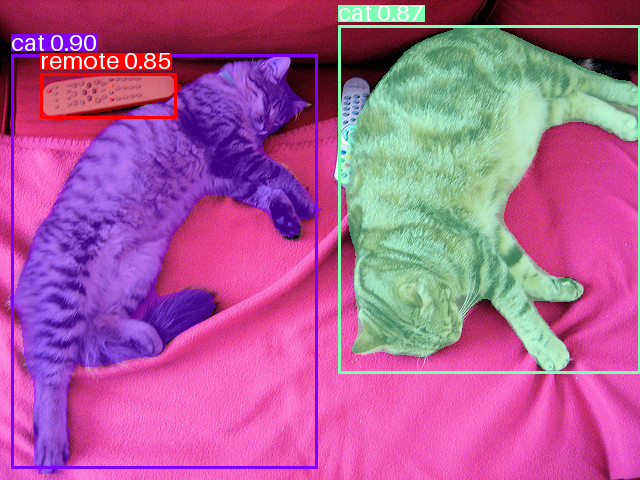

In [14]:
# Load image
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

results = detect_image(image)
print(f"Found {len(results['masks'])} objects")
result = overlay_masks(image, results["masks"])
result = overlay_boxes(result, results["boxes"], results["labels"], results["scores"])
result

Found 7 objects


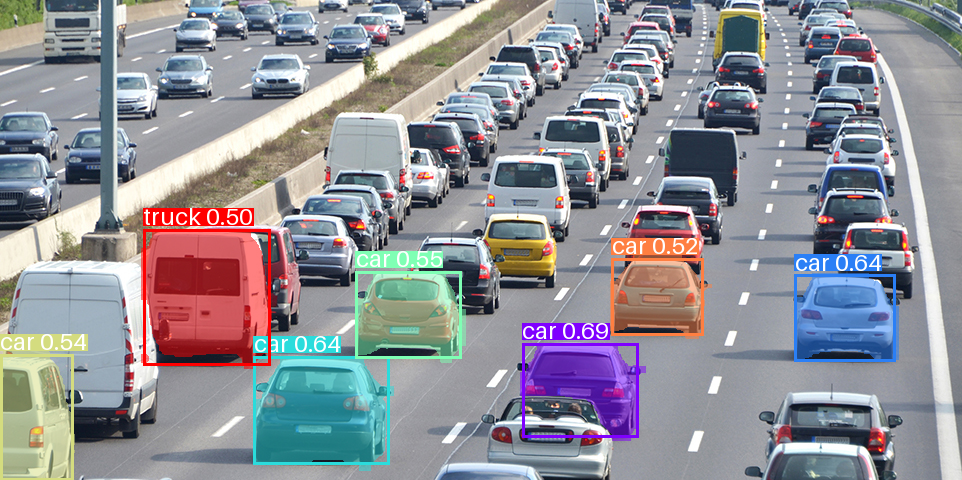

In [15]:
# Load highway image
highway = Image.open("images/highway.jpg").convert("RGB")

results = detect_image(highway)
print(f"Found {len(results['masks'])} objects")
result = overlay_masks(highway, results["masks"])
result = overlay_boxes(result, results["boxes"], results["labels"], results["scores"])
result